In [1]:
import requests
import pandas as pd
import os
import json
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
def load_data_from_api():

    url = "https://ll.thespacedevs.com/2.0.0/launch/upcoming"

    try:
        response = requests.get(url)
        data = response.json()

        os.makedirs("data", exist_ok=True)

        with open("data/launches.json", "w") as f:
            json.dump(data, f)

        df = pd.DataFrame(data["results"])

        print("Data saved to data/launches.json")
        print("DataFrame preview:")
        print(df.head())

        return df

    except Exception as e:
        print("API Error:", e)

In [3]:
df = load_data_from_api()

Data saved to data/launches.json
DataFrame preview:
                                     id  \
0  2e3e33a1-b87d-4d52-a7e7-8cc5a28046fd   
1  1d24bfe7-d524-41f0-85de-09e967618710   
2  6f2868b8-1000-48e5-893b-700c1371b4fb   
3  d44f47c7-5e3e-40fb-9d10-b6e851acf81a   
4  f8766455-2b03-4629-a36e-b931c8b4a6c5   

                                                 url launch_library_id  \
0  https://ll.thespacedevs.com/2.0.0/launch/2e3e3...              None   
1  https://ll.thespacedevs.com/2.0.0/launch/1d24b...              None   
2  https://ll.thespacedevs.com/2.0.0/launch/6f286...              None   
3  https://ll.thespacedevs.com/2.0.0/launch/d44f4...              None   
4  https://ll.thespacedevs.com/2.0.0/launch/f8766...              None   

                                    slug  \
0      long-march-8a-satnet-leo-group-20   
1          long-march-2d-shiyan-30-03-04   
2  falcon-9-block-5-starlink-group-10-48   
3  falcon-9-block-5-starlink-group-17-31   
4          long-march-6a

In [4]:
def get_pictures():

    with open("data/launches.json") as f:
        data = json.load(f)

    launches = data["results"]

    os.makedirs("images", exist_ok=True)

    for i, launch in enumerate(launches):

        image_url = launch.get("image")

        if image_url:
            try:
                img = requests.get(image_url)

                with open(f"images/img_{i}.jpg", "wb") as f:
                    f.write(img.content)

                print("Downloaded:", image_url)

            except:
                print("Failed to download image")

In [ ]:
get_pictures()

Downloaded: https://thespacedevs-prod.nyc3.digitaloceanspaces.com/media/images/cz-8a_launch_2_image_20251206093107.jpeg
Downloaded: https://thespacedevs-prod.nyc3.digitaloceanspaces.com/media/images/long2520march25202d_image_20190222031211.jpeg
Downloaded: https://thespacedevs-prod.nyc3.digitaloceanspaces.com/media/images/falcon2520925_image_20221009234147.png
Downloaded: https://thespacedevs-prod.nyc3.digitaloceanspaces.com/media/images/falcon2520925_image_20221009234147.png
Downloaded: https://thespacedevs-prod.nyc3.digitaloceanspaces.com/media/images/long_march_6a__image_20251209050223.jpeg
Downloaded: https://thespacedevs-prod.nyc3.digitaloceanspaces.com/media/images/kuaizhou_1a_lau_image_20251206092920.jpeg


In [6]:
import os
import math
import matplotlib.pyplot as plt
from PIL import Image

def show_images():

    folder = "images"
    files = os.listdir(folder)

    files.sort()

    n = len(files)
    cols = 5
    rows = math.ceil(n / cols)

    plt.figure(figsize=(15, rows*3))

    for i, file in enumerate(files):

        img = Image.open(os.path.join(folder, file))

        plt.subplot(rows, cols, i+1)
        plt.imshow(img)
        plt.title(file[:15], fontsize=8)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

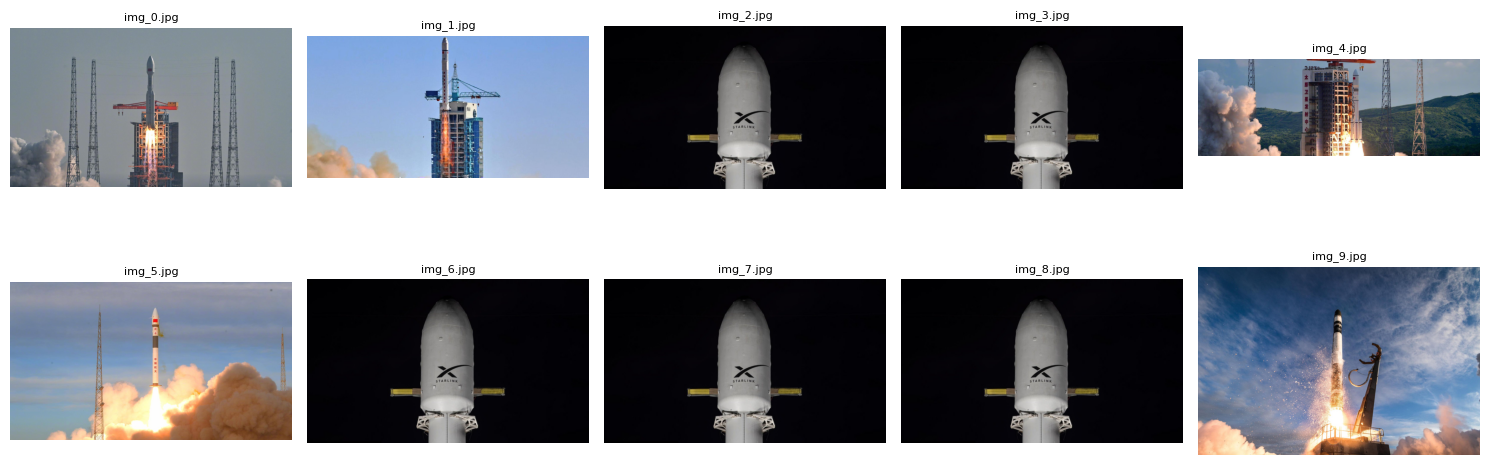

In [7]:
show_images()